In [3]:
!pip install pandas numpy matplotlib seaborn scikit-learn streamlit joblib


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 30.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 46.6 MB/s eta 0:00:00


   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa

Shape of Dataset:
(150, 6)

Column Names:
Index(['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm',
       'Species'],
      dtype='object')

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-n

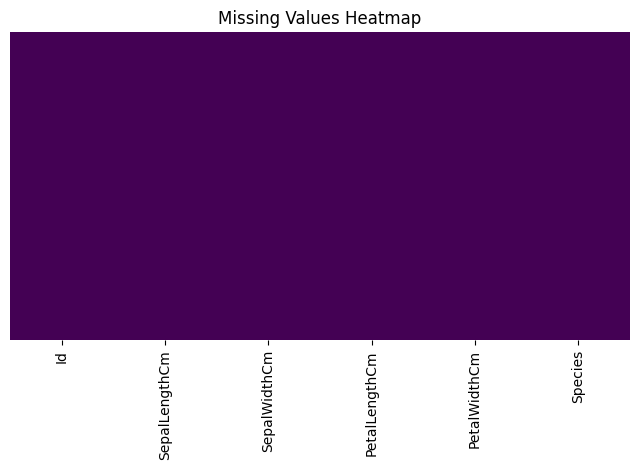


Duplicate Rows: 0


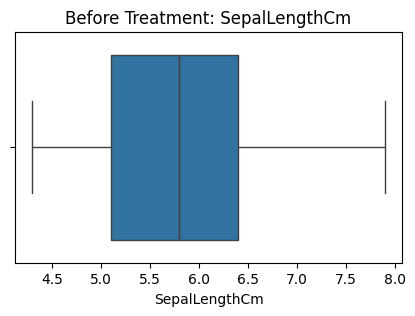

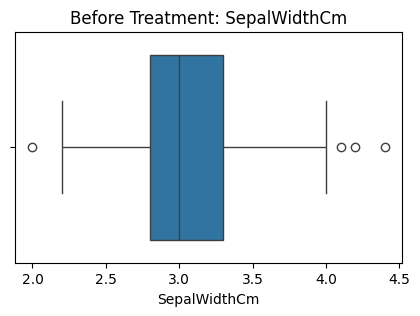

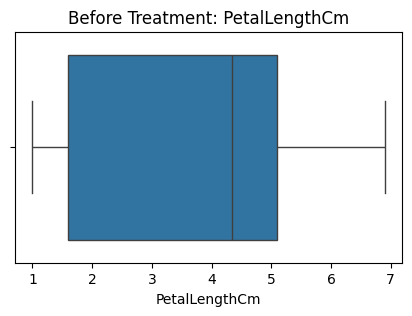

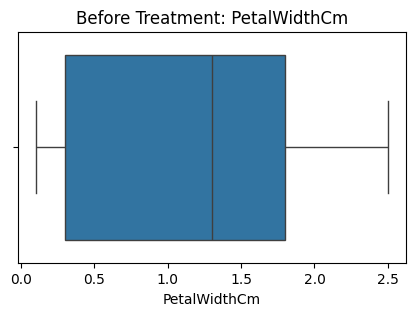


Rows before treatment: 150
Rows after treatment: 146


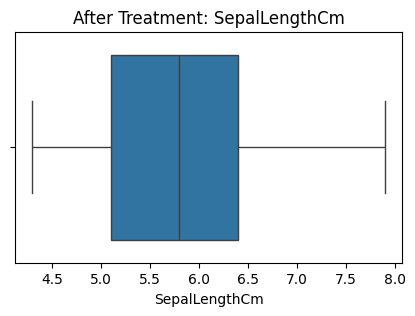

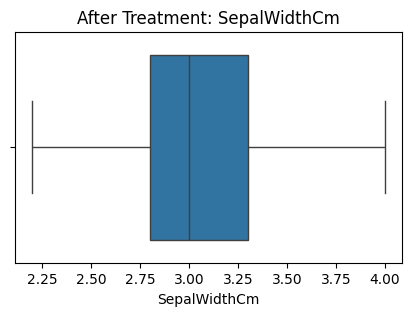

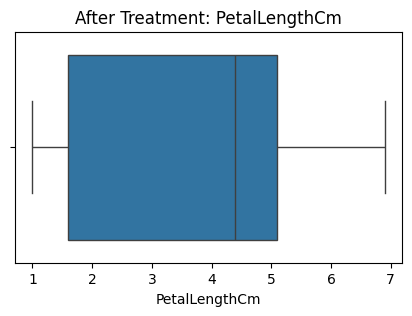

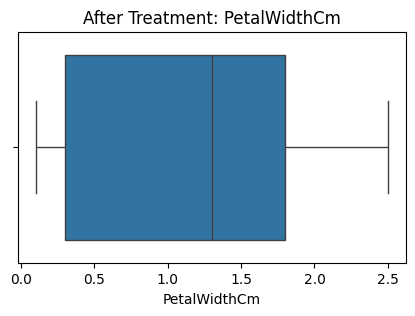

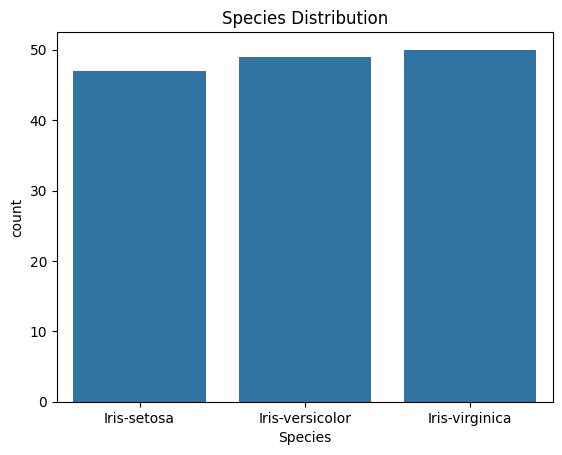

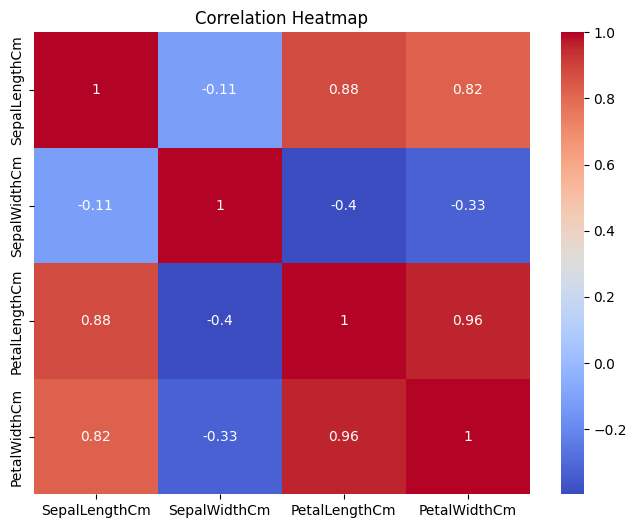

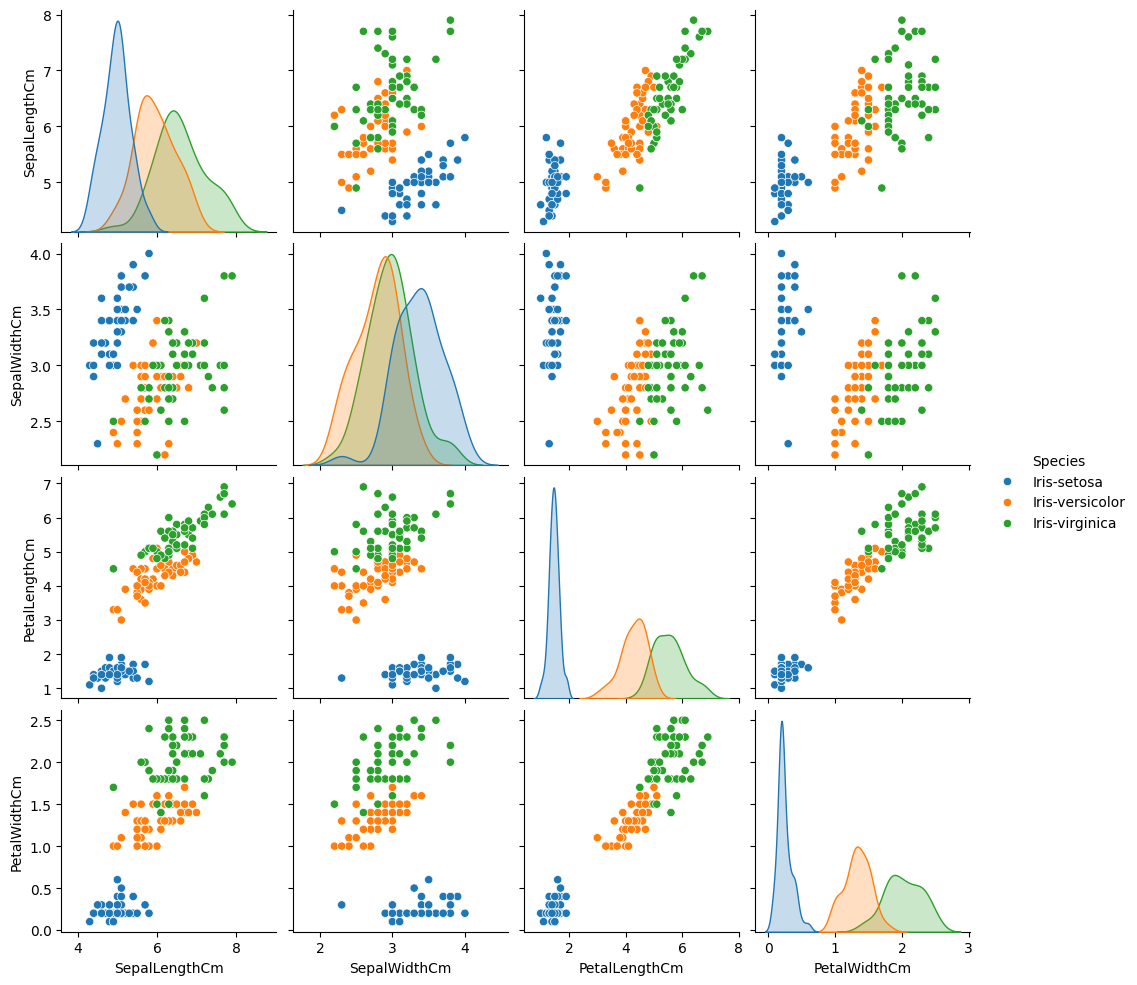

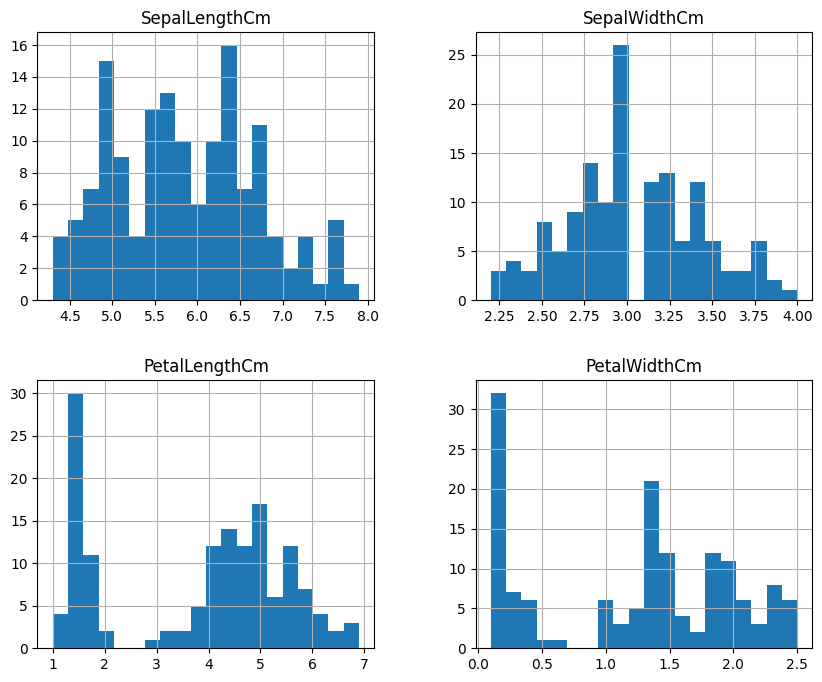


Skewness:
SepalLengthCm    0.278417
SepalWidthCm     0.140812
PetalLengthCm   -0.323649
PetalWidthCm    -0.148777
dtype: float64

Model Accuracies:
SVM: 0.9667
Random Forest: 0.9333
Decision Tree: 0.9333
KNN: 0.8667
Logistic Regression: 0.9333


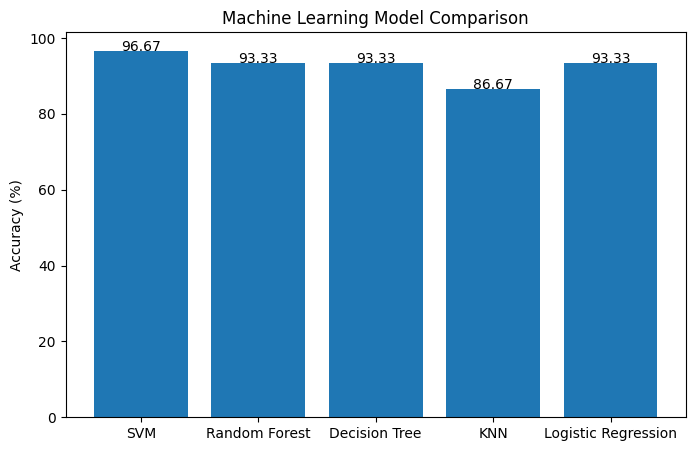

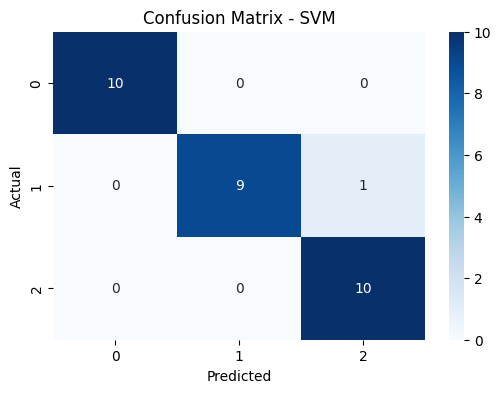


Classification Report:

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      0.90      0.95        10
 Iris-virginica       0.91      1.00      0.95        10

       accuracy                           0.97        30
      macro avg       0.97      0.97      0.97        30
   weighted avg       0.97      0.97      0.97        30


Best model saved as model.pkl


In [1]:
# =========================
# IMPORT LIBRARIES
# =========================

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# =========================
# LOAD DATASET
# =========================

df = pd.read_csv("C:\\Users\\merline\\Downloads\\Iris (2).csv")

print(df.head())

print("\nShape of Dataset:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nDataset Information:")
print(df.info())

print("\nStatistical Summary:")
print(df.describe())

print("\nData Types:")
print(df.dtypes)

# =========================
# MISSING VALUES
# =========================

print("\nMissing Values:")
print(df.isnull().sum())

plt.figure(figsize=(8,4))

sns.heatmap(
    df.isnull(),
    cmap='viridis',
    cbar=False,
    yticklabels=False
)

plt.title("Missing Values Heatmap")
plt.show()

# =========================
# DUPLICATES
# =========================

print("\nDuplicate Rows:", df.duplicated().sum())

# =========================
# DROP ID COLUMN
# =========================

df = df.drop("Id", axis=1)

# =========================
# NUMERIC COLUMNS
# =========================

num_cols = df.select_dtypes(include=np.number).columns

# =========================
# OUTLIER DETECTION
# =========================

for col in num_cols:
    plt.figure(figsize=(5,3))
    sns.boxplot(x=df[col])
    plt.title(f"Before Treatment: {col}")
    plt.show()

# =========================
# OUTLIER TREATMENT (IQR)
# =========================

df_clean = df.copy()

for col in num_cols:

    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df_clean = df_clean[
        (df_clean[col] >= lower) &
        (df_clean[col] <= upper)
    ]

print("\nRows before treatment:", len(df))
print("Rows after treatment:", len(df_clean))

# Use cleaned dataset
df = df_clean.copy()

# =========================
# OUTLIER VISUALIZATION AFTER
# =========================

for col in num_cols:
    plt.figure(figsize=(5,3))
    sns.boxplot(x=df[col])
    plt.title(f"After Treatment: {col}")
    plt.show()

# =========================
# SPECIES DISTRIBUTION
# =========================

sns.countplot(
    x='Species',
    data=df
)

plt.title("Species Distribution")
plt.show()

# =========================
# CORRELATION HEATMAP
# =========================

plt.figure(figsize=(8,6))

sns.heatmap(
    df.drop('Species', axis=1).corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()

# =========================
# PAIRPLOT
# =========================

sns.pairplot(
    df,
    hue='Species'
)

plt.show()

# =========================
# HISTOGRAMS
# =========================

df.hist(
    figsize=(10,8),
    bins=20
)

plt.show()

# =========================
# SKEWNESS
# =========================

print("\nSkewness:")
print(df.skew(numeric_only=True))

# =========================
# LABEL ENCODING
# =========================

from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

df['Species'] = encoder.fit_transform(
    df['Species']
)

# =========================
# FEATURES & TARGET
# =========================

X = df.drop('Species', axis=1)
y = df['Species']

# =========================
# TRAIN TEST SPLIT
# =========================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# =========================
# FEATURE SCALING
# =========================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# =========================
# MODEL TRAINING
# =========================

from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

results = {}

# SVM
svm = SVC()
svm.fit(X_train_scaled, y_train)

svm_pred = svm.predict(X_test_scaled)

results["SVM"] = accuracy_score(y_test, svm_pred)

# Random Forest
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

results["Random Forest"] = accuracy_score(y_test, rf_pred)

# Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

results["Decision Tree"] = accuracy_score(y_test, dt_pred)

# KNN
knn = KNeighborsClassifier()
knn.fit(X_train_scaled, y_train)

knn_pred = knn.predict(X_test_scaled)

results["KNN"] = accuracy_score(y_test, knn_pred)

# Logistic Regression
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train_scaled, y_train)

lr_pred = lr.predict(X_test_scaled)

results["Logistic Regression"] = accuracy_score(y_test, lr_pred)

# =========================
# MODEL RESULTS
# =========================

print("\nModel Accuracies:")

for model, score in results.items():
    print(f"{model}: {score:.4f}")

# =========================
# COMPARISON CHART
# =========================

plt.figure(figsize=(8,5))

bars = plt.bar(
    results.keys(),
    [score*100 for score in results.values()]
)

plt.ylabel("Accuracy (%)")
plt.title("Machine Learning Model Comparison")

for bar in bars:
    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height(),
        f"{bar.get_height():.2f}",
        ha='center'
    )

plt.show()

# =========================
# CONFUSION MATRIX (BEST MODEL)
# =========================

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, svm_pred)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    cmap='Blues',
    fmt='d'
)

plt.title("Confusion Matrix - SVM")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# =========================
# CLASSIFICATION REPORT
# =========================

from sklearn.metrics import classification_report

print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        svm_pred,
        target_names=encoder.classes_
    )
)

# =========================
# SAVE BEST MODEL
# =========================

import joblib

joblib.dump(
    svm,
    "model.pkl"
)

print("\nBest model saved as model.pkl")

In [9]:
from google.colab import files

files.download("model.pkl")
import joblib

joblib.dump(scaler, "scaler.pkl")
from google.colab import files

files.download("scaler.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [34]:
import streamlit as st
import joblib
import numpy as np

model = joblib.load("model.pkl")

st.title("Iris Flower Prediction System")

sl = st.slider(
    "Sepal Length",
    4.0,
    8.0,
    5.0
)

sw = st.slider(
    "Sepal Width",
    2.0,
    5.0,
    3.0
)

pl = st.slider(
    "Petal Length",
    1.0,
    7.0,
    4.0
)

pw = st.slider(
    "Petal Width",
    0.1,
    3.0,
    1.0
)

if st.button("Predict"):

    prediction = model.predict(
        [[sl,sw,pl,pw]]
    )

    st.success(
        f"Predicted Species: {prediction[0]}"
    )

2026-06-13 07:45:55.843 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-13 07:45:56.164 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-06-13 07:45:56.169 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-13 07:45:56.170 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-13 07:45:56.177 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-13 07:45:56.179 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-13 07:45:56.181 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-13 07:45:56.188 Thread 'MainThread': mi

In [35]:
!pip install streamlit pyngrok
%%writefile app.py

import streamlit as st

st.title("Iris Flower Prediction")
st.write("Hello Streamlit!")


UsageError: Line magic function `%%writefile` not found.


In [7]:
import joblib

joblib.dump(svm, "model.pkl")
joblib.dump(scaler, "scaler.pkl")
from google.colab import files

files.download("model.pkl")
files.download("scaler.pkl")

NameError: name 'SepalLengthCm' is not defined